In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/facial-keypoints-detection/training.zip
/kaggle/input/competitions/facial-keypoints-detection/SampleSubmission.csv
/kaggle/input/competitions/facial-keypoints-detection/IdLookupTable.csv
/kaggle/input/competitions/facial-keypoints-detection/test.zip


In [182]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
loss_history, new_entry = {},0

In [5]:
import zipfile 
with zipfile.ZipFile('/kaggle/input/competitions/facial-keypoints-detection/training.zip','r') as f:
    f.extractall()

In [6]:
df = pd.read_csv("/kaggle/working/training.csv")

In [7]:
df.columns

Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y', 'Image'],
      dtype='object')

In [8]:
def shape_to_tuple(shape):
    return tuple(None if d is None else int(d) for d in shape)

def model_to_dict(model):
    model_dict = {
        "name": model.name,
        "layers": [],
        "total_params": model.count_params()
    }

    for i, layer in enumerate(model.layers):
        layer_info = {
            "index": i,
            "name": layer.name,
            "class": layer.__class__.__name__,
            "output_shape": shape_to_tuple(layer.output.shape),
            "num_params": layer.count_params(),
        }

        if isinstance(layer, tf.keras.layers.Conv2D):
            layer_info["filters"] = layer.filters
            layer_info["kernel_size"] = layer.kernel_size
            layer_info["strides"] = layer.strides
            layer_info["padding"] = layer.padding
            layer_info["activation"] = layer.activation.__name__

        elif isinstance(layer, tf.keras.layers.Dense):
            layer_info["units"] = layer.units
            layer_info["activation"] = layer.activation.__name__

        model_dict["layers"].append(layer_info)

    return model_dict

In [9]:
h = w = int(math.sqrt(len(df.iloc[0,-1].split(" "))))

In [208]:
tf.random.set_seed(42)
np.random.seed(42)
X = np.vstack(df.iloc[:,-1].apply(lambda x: np.fromstring(x,dtype=np.float32,sep=' '))).reshape((-1,w,h,1)) / 255.0
y = df.iloc[:,:-1]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
scalar = StandardScaler()
scalar.fit(y_train)
y_train = scalar.transform(y_train)
y_test = scalar.transform(y_test)

In [210]:
submission_scalar = StandardScaler()
y = submission_scalar.fit_transform(y)

In [13]:
def show_image(img,values):
    print(f"idx: {idx}")
    # img = X[idx]
    plt.imshow(img,cmap="gist_gray")
    tmp = np.reshape(values,(-1,2))
    plt.scatter(tmp[:,0],tmp[:,1])

idx: 5846


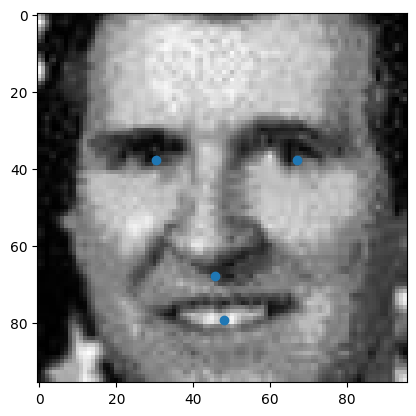

In [14]:
idx = np.random.randint(X.shape[0])
show_image(X[idx],y.iloc[idx])

In [15]:
def masked_mse(y_true,y_pred):
    mask = tf.math.is_finite(y_true)
    y_true = tf.where(mask,y_true,0.0)
    y_pred = tf.where(mask,y_pred,0.0)

    mse = tf.square(y_true- y_pred)
    
    return tf.reduce_sum(mse) / tf.reduce_sum(tf.cast(mask,tf.float32))

def masked_mae(y_true,y_pred):
    mask = tf.math.is_finite(y_true)
    y_true = tf.where(mask,y_true,0.0)
    y_pred = tf.where(mask,y_pred,0.0)

    mse = tf.abs(y_true- y_pred)
    
    return tf.reduce_sum(mse) / tf.reduce_sum(tf.cast(mask,tf.float32))

In [211]:
config = {
    "desc": "global->averagePooling2D+Flatten",

    #Conv2D
    "kernel_size": (3,3),
    "strides": (1,1),
    "padding": "same", #valid
    "kernel_initializer": "he_normal",
    "activation": "gelu",

    #MaxPool2D
    "pool_size": (2,2),

    #AveragePool2D
    "average_pool_size": 6, # BE VERY CAREFUL

    #Dropout:
    "rate": 0.2,

    #optimizer
    "learning_rate": 1e-3,

    #fit
    "batch_size": 64,
    "epochs": 40,
    "early_stopping": True, # reverse
    "patience": 8,
    "start_from_epoch": 20,
    "validation_split": 0.2 # reverse
}
tf.random.set_seed(42)
np.random.seed(42)

In [212]:
model = tf.keras.Sequential([
    tf.keras.Input((w,h,1)),
    # tf.keras.layers.Conv2D(
    #     filters=32,
    #     kernel_size=config["kernel_size"],
    #     strides=config["strides"],
    #     padding=config["padding"],
    #     kernel_initializer=config["kernel_initializer"]
    # ),
    # tf.keras.layers.BatchNormalization(),
    # tf.keras.layers.Activation(config["activation"]),
    # tf.keras.layers.SpatialDropout2D(config["rate"]),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=config["kernel_size"],
        strides=config["strides"],
        padding=config["padding"],
        kernel_initializer=config["kernel_initializer"]
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation(config["activation"]),
    
    tf.keras.layers.MaxPool2D(config["pool_size"]),
    tf.keras.layers.SpatialDropout2D(config["rate"]),
    
    # tf.keras.layers.Conv2D(
    #     filters=64,
    #     kernel_size=config["kernel_size"],
    #     strides=config["strides"],
    #     padding=config["padding"],
    #     kernel_initializer=config["kernel_initializer"]
    # ),
    # tf.keras.layers.BatchNormalization(),
    # tf.keras.layers.Activation(config["activation"]),
    # tf.keras.layers.SpatialDropout2D(config["rate"]),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=config["kernel_size"],
        strides=config["strides"],
        padding=config["padding"],
        kernel_initializer=config["kernel_initializer"]
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation(config["activation"]),
    tf.keras.layers.MaxPool2D(config["pool_size"]),
    tf.keras.layers.SpatialDropout2D(config["rate"]),
    
    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=config["kernel_size"],
        strides=config["strides"],
        padding=config["padding"],
        kernel_initializer=config["kernel_initializer"],
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation(config["activation"]),
    
    tf.keras.layers.AveragePooling2D(config["average_pool_size"]),
    # tf.keras.layers.SpatialDropout2D(config["rate"]),
    # dropping whole filters right before a flatten is generally not a good idea
    
    # WeightDecay
    #BatchNorm? 
    # tf.keras.layers.GlobalAveragePooling2D(), # tf.keras.layers.Flatten()
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(64,kernel_initializer=config["kernel_initializer"]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation(config["activation"]),
    
    tf.keras.layers.Dense(30,kernel_initializer=config["kernel_initializer"]),
    
])

model.compile(
    optimizer=tf.keras.optimizers.AdamW(config["learning_rate"]),
    loss=masked_mse,
    metrics=[masked_mae]
)

config["model_summary"] = model_to_dict(model)

model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_78 (Conv2D)              │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_58 (Activation)      │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_43            │ (None, 48, 48, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_59 (Activation)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_44            │ (None, 24, 24, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_60 (Activation)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 4, 4, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_61 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,910 (886.37 KB)

 Trainable params: 226,334 (884.12 KB)

 Non-trainable params: 576 (2.25 KB)

In [213]:
print(f"{new_entry}:")
history = model.fit(
    X_train,y_train, #reverse
    batch_size=config["batch_size"],
    epochs=config["epochs"],
    callbacks = [] if not config["early_stopping"] else 
    [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=config["patience"],
            start_from_epoch=config["start_from_epoch"]
            # restore_best_weight=True for the end
        )
    ],
    validation_split=config["validation_split"]
)
eval_res = model.evaluate(X_test,y_test)
print(eval_res)
loss_history[new_entry] = {"params": config,"history":history.history,"evaluate":eval_res}
new_entry+=1

14:
Epoch 1/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - loss: 1.2538 - masked_mae: 0.7919
Epoch 2/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.8918 - masked_mae: 0.6383
Epoch 3/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.7370 - masked_mae: 0.5641
Epoch 4/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.6250 - masked_mae: 0.5143
Epoch 5/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.5547 - masked_mae: 0.4823
Epoch 6/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.5067 - masked_mae: 0.4594
Epoch 7/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.4669 - masked_mae: 0.4415
Epoch 8/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.4393 - masked_mae: 0.4300
Epoch 9/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.4078 - masked_mae: 0.4169
Epoch 10/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.3823 - masked_mae: 0.4067
Epoch 11/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.3656 - masked_mae: 0.3972
Epoch 12/40
11

0: [0.6495210528373718, 0.52811199426651]
6: [0.9318057894706726, 0.6637894511222839]
9: [0.6337743401527405, 0.5149662494659424]
12: [0.618854284286499, 0.5144463777542114]
13: [0.39027851819992065, 0.417464017868042]
14: [0.13130035996437073, 0.27264896035194397]


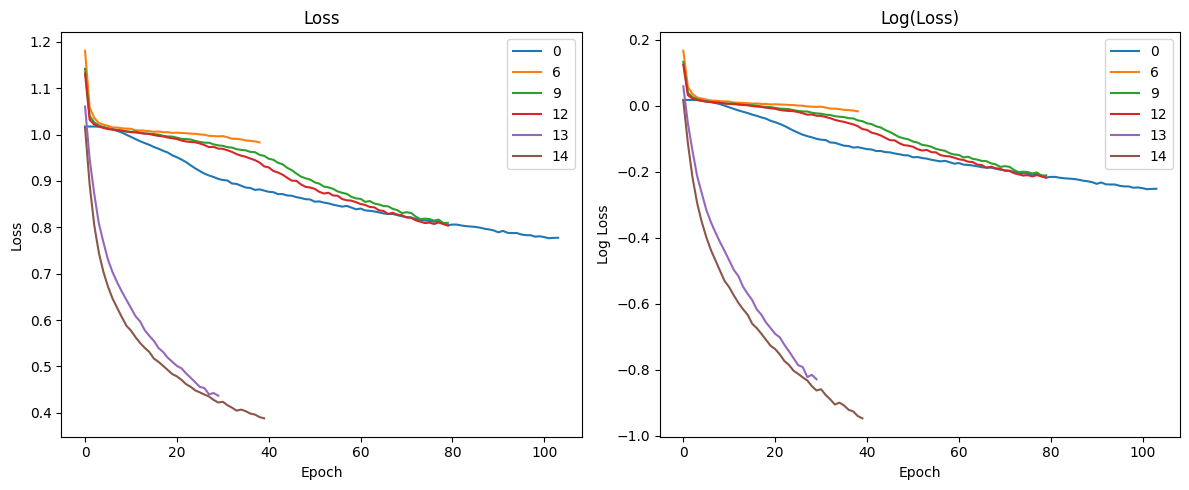

In [214]:
excluded_runs = {1,5,7,8,
                 10, # deep network
                 11, 14, #submission
                } 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Left plot — actual loss
for i in loss_history.keys():
    if i in excluded_runs: continue
    loss_vals = loss_history[i]['history']['loss']
    axes[0].plot(np.sqrt(loss_vals), label=i)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()


# Right plot — log loss
for i in loss_history.keys():
    if i in excluded_runs: continue
    print(f"{i}: {loss_history[i].get('evaluate',[])}")
    loss_vals = loss_history[i]['history']['loss']
    axes[1].plot(np.log(loss_vals)/2, label=i)

axes[1].set_title("Log(Loss)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Log Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [231]:
for i in loss_history.keys():
    if i in excluded_runs: continue
    print(i,loss_history[i]["params"]["desc"])

0 increased epochs
6 added batchNorm
9 improved EarlyStopping + gelu
12 not deep architecture+AdamW
13 global->averagePooling2D+Flatten
14 submission run


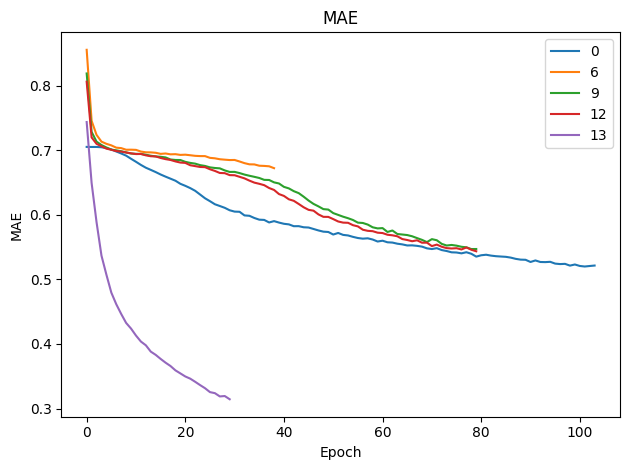

In [199]:
for i in loss_history.keys():
    if i in excluded_runs: continue
    acc_vals = loss_history[i]['history'].get('masked_mae',[])
    plt.plot(acc_vals, label=i)

plt.title("MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

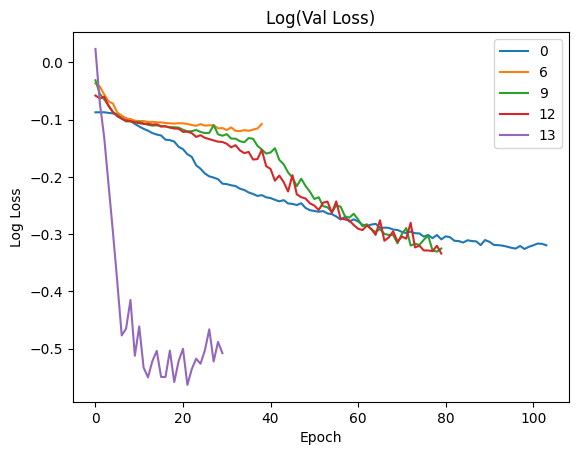

In [200]:
for i in loss_history.keys():
    if i in excluded_runs: continue
    loss_vals = loss_history[i]['history'].get("val_loss",[])
    plt.plot(np.log(loss_vals)/2, label=i)

plt.title("Log(Val Loss)")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()

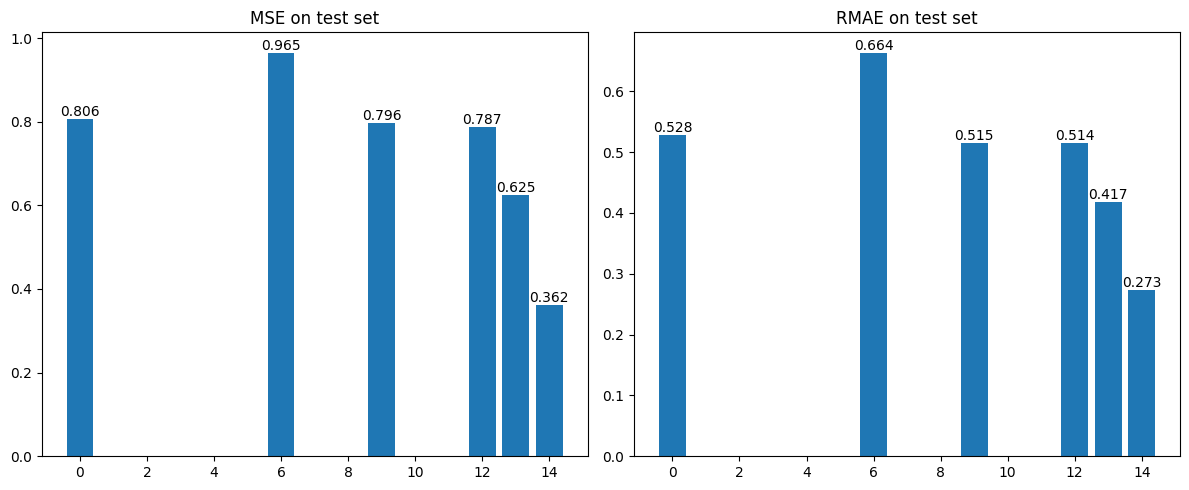

In [215]:
x,h1,h2=[],[],[]
for i in loss_history.keys():
    if i in excluded_runs: continue
    x.append(i)
    h1.append(np.sqrt(loss_history[i].get('evaluate',[0,0])[0]))
    h2.append(loss_history[i].get('evaluate',[0,0])[1])

fig,axes = plt.subplots(1,2,figsize=(12,5))

bars1 = axes[0].bar(x,h1)
axes[0].set_title("MSE on test set")
axes[0].bar_label(bars1, fmt='%.3f')


bars2 = axes[1].bar(x,h2)
axes[1].set_title("RMAE on test set")
axes[1].bar_label(bars2, fmt='%.3f')

plt.tight_layout()

In [232]:
with open("loss_history.json","w") as f:
    json.dump(loss_history,f)

In [234]:
interesting_runs = {i: loss_history[i] for i in [11,14]}
with open("interesting.json","w") as f:
    json.dump(interesting_runs,f)

In [107]:
import zipfile
with zipfile.ZipFile('/kaggle/input/competitions/facial-keypoints-detection/test.zip','r') as f:
    f.extractall()

In [108]:
featurelookuptable = {idx:i for i,idx in enumerate(df.columns[:-1])}

In [109]:
sampleSubmission = pd.read_csv("/kaggle/input/competitions/facial-keypoints-detection/SampleSubmission.csv")

idLookuptable = pd.read_csv("/kaggle/input/competitions/facial-keypoints-detection/IdLookupTable.csv")
idLookuptable['FeatureIdx'] = [featurelookuptable[i] for i in idLookuptable['FeatureName']]

test_df = pd.read_csv("/kaggle/working/test.csv")
inp = np.vstack([np.fromstring(i,sep=" ") for i in test_df.iloc[:,-1]]).reshape((-1,w,h,1)).astype(np.float32) / 255.0

In [216]:
model_res = scalar.inverse_transform(model.predict(inp)) # reverse
model_res = np.where(model_res < 96.0,model_res,96.0)
sampleSubmission['Location'] = [model_res[i[0]-1,i[1]] for i in np.array(idLookuptable.loc[:,['ImageId',"FeatureIdx"]])]

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


idx: 5390


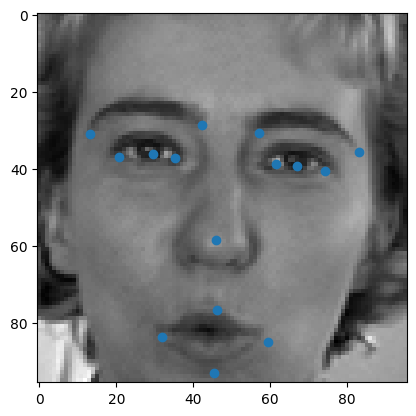

In [223]:
idx = np.random.randint(0,idLookuptable.shape[0])
rowIdx = 245# idLookuptable.iloc[idx,:]['ImageId']
show_image(inp[rowIdx,:],model_res[rowIdx,:])

In [226]:
sampleSubmission.to_csv("/kaggle/working/submission.csv",index=False)